In [2]:
ls "/mnt/Internal/MedImage/chexpert_1000_per_disease.csv"

 chexpert/                       hf/                        NewFolderName/
 chexpert_1000_per_disease.csv   lab2_rotation/
'CheXpert Dataset'/              merged_dataset-Copy1.csv


In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
import warnings
warnings.simplefilter("ignore", FutureWarning)

In [4]:
import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, UnidentifiedImageError
from diffusers import UNet2DModel, DDPMScheduler
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paths
image_root = "/mnt/Internal/MedImage/CheXpert Dataset/unzip_chexpert_images/CheXpert-v1.0/train"
output_dir = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt"
os.makedirs(output_dir, exist_ok=True)

# Load dataset
train_df_full = pd.read_csv("/mnt/Internal/MedImage/chexpert_1000_per_disease.csv")
#train_df_full = train_df_full[train_df_full['Frontal/Lateral'].str.contains('frontal', case=False, na=False)]
#train_df_full.replace(-1, 1, inplace=True)
#train_df_full.replace(np.nan, 0, inplace=True)

# Train-Validation Split
valid_df = train_df_full[13981:14002]
train_df = train_df_full[0:13980]

# Dataset class
class CheXpertDataset(Dataset):
    def __init__(self, dataframe, image_root, transform=None):
        self.dataframe = dataframe
        self.image_root = image_root
        self.transform = transform
        self.valid_images = []

        for idx in range(len(dataframe)):
            item = dataframe.iloc[idx]
            img_path = item['Path'].replace("CheXpert-v1.0/train/", "")
            full_path = os.path.join(self.image_root, img_path)
            if os.path.exists(full_path):
                self.valid_images.append((full_path, item))

        if len(self.valid_images) == 0:
            raise ValueError(f"No valid images found in: {image_root}")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_path, item = self.valid_images[idx]
        try:
            image = Image.open(img_path).convert("RGB")
        except (FileNotFoundError, IOError, UnidentifiedImageError):
            return None
        
        if self.transform:
            image = self.transform(image)
        
        label = item[['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
                      'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
                      'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']].values.astype(np.float32)
        return image, torch.tensor(label, dtype=torch.float32)

def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return torch.empty(0), torch.empty(0)
    images, labels = zip(*batch)
    images = torch.stack([torch.from_numpy(np.array(img)).float() for img in images])
    labels = torch.stack(labels)
    return images, labels

# Preprocessing
preprocess = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = CheXpertDataset(train_df, image_root, transform=preprocess)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
valid_dataset = CheXpertDataset(valid_df, image_root, transform=preprocess)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

# Debugging Dataset
print(f"Training Samples: {len(train_dataset)}")
print(f"Validation Samples: {len(valid_dataset)}")

# Define Model with Label Conditioning
class ConditionalUNet(torch.nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        self.unet = UNet2DModel(
            sample_size=256, in_channels=3, out_channels=3,
            layers_per_block=2, block_out_channels=(128, 256, 512, 512),
            down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D")
        )
        self.label_embedding = torch.nn.Linear(num_classes, 512)  
        self.label_proj = torch.nn.Linear(512, 3)  

    def forward(self, x, t, labels):
        label_embedding = self.label_embedding(labels)  
        label_embedding = self.label_proj(label_embedding)  
        label_embedding = label_embedding[:, :, None, None] 
        
        x = x + label_embedding  
        return self.unet(x, t)


# Initialize Model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ConditionalUNet().to(device)
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = optim.AdamW(model.parameters(), lr=5e-5)


Training Samples: 13980
Validation Samples: 19


In [ ]:


# # Define total number of epochs for training
# total_epochs = 90  # Change this to extend training

# # Resume Training
# start_epoch = 64
# checkpoint_path = os.path.join(output_dir, "latest_checkpoint.pth")

# if os.path.exists(checkpoint_path):
#     checkpoint = torch.load(checkpoint_path)
#     model.load_state_dict(checkpoint["model_state"])
#     optimizer.load_state_dict(checkpoint["optimizer_state"])
#     start_epoch = checkpoint["epoch"] + 1
#     print(f"Resuming training from epoch {start_epoch}")


# # Training Loop
# for epoch in range(start_epoch, total_epochs):
#     model.train()
#     epoch_loss = 0
#     progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{total_epochs}")
    
#     for images, labels in progress_bar:
#         images, labels = images.to(device), labels.to(device)
#         noise = torch.randn_like(images).to(device)
#         timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (images.shape[0],), device=device).long()
#         noisy_images = noise_scheduler.add_noise(images, noise, timesteps)
        
#         predictions = model(noisy_images, timesteps, labels).sample
#         loss = torch.nn.functional.mse_loss(predictions, noise)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         epoch_loss += loss.item()
#         progress_bar.set_postfix({"loss": loss.item()})

#     print(f"Epoch {epoch + 1}: Average Loss = {epoch_loss / len(train_loader)}")

#     # Save checkpoint
#     torch.save({
#         "epoch": epoch,
#         "model_state": model.state_dict(),
#         "optimizer_state": optimizer.state_dict(),
#     }, checkpoint_path)

#     # Save model per epoch
#     torch.save(model.state_dict(), os.path.join(output_dir, f"model_epoch_{epoch + 1}.pth"))
# print("training complete")

### For New Training Steps

In [5]:
# Resume Training
start_epoch = 77  # Start from the next epoch
total_epochs = 90  # Train up to 60 epochs

checkpoint_path = os.path.join(output_dir, "latest_checkpoint.pth")
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming training from epoch {start_epoch}")

# Adjust training steps
new_training_steps = 2000  # Increase steps per epoch

# Training Loop
for epoch in range(start_epoch, total_epochs):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(range(new_training_steps), desc=f"Epoch {epoch}/{total_epochs}")

    train_loader_iter = iter(train_loader)  # Create an iterator

    for step in progress_bar:
        try:
            images, labels = next(train_loader_iter)  # Get next batch
        except StopIteration:
            train_loader_iter = iter(train_loader)  # Reset if exhausted
            images, labels = next(train_loader_iter)

        images, labels = images.to(device), labels.to(device)
        noise = torch.randn_like(images).to(device)
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)
        
        predictions = model(noisy_images, timesteps, labels).sample
        loss = torch.nn.functional.mse_loss(predictions, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    print(f"Epoch {epoch}: Average Loss = {epoch_loss / new_training_steps}")

    # Save checkpoint
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, checkpoint_path)

    # Save model per epoch
    torch.save(model.state_dict(), os.path.join(output_dir, f"model_epoch_{epoch}.pth"))

print("Training complete!")

Resuming training from epoch 78


Epoch 78/90: 100%|██████████| 2000/2000 [38:00<00:00,  1.14s/it, loss=0.00419] 


Epoch 78: Average Loss = 0.0047335957993800545


Epoch 79/90: 100%|██████████| 2000/2000 [37:52<00:00,  1.14s/it, loss=0.00193] 


Epoch 79: Average Loss = 0.004459390665548199


...

Epoch 87: Average Loss = 0.0044495856740904855


Epoch 88/90: 100%|██████████| 2000/2000 [37:57<00:00,  1.14s/it, loss=0.0133]  


Epoch 88: Average Loss = 0.004655423201343183


Epoch 89/90: 100%|██████████| 2000/2000 [37:40<00:00,  1.13s/it, loss=0.00279] 


Epoch 89: Average Loss = 0.00464318353042745
Training complete!


Saved: /mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt/rough_folder_for_img_checking/Edema1.png


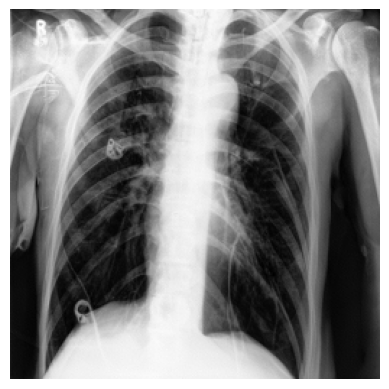

Saved: /mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt/rough_folder_for_img_checking/Edema2.png


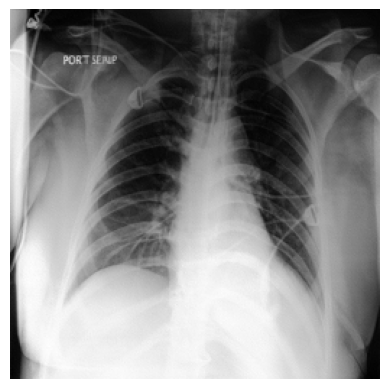

Saved: /mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt/rough_folder_for_img_checking/Edema3.png


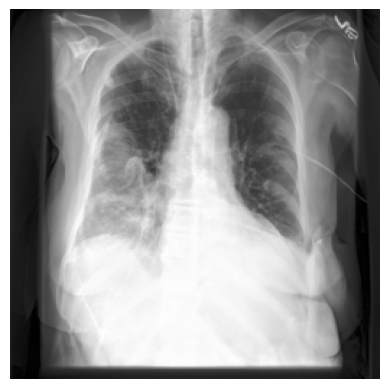

In [37]:
from diffusers import UNet2DModel, DDPMScheduler  # Ensure UNet2DModel is imported
import torch
import os
from torch import nn
import matplotlib.pyplot as plt

# Define your model class again (same as in training code)
class ConditionalUNet(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        self.unet = UNet2DModel(
            sample_size=256, in_channels=3, out_channels=3,
            layers_per_block=2, block_out_channels=(128, 256, 512, 512),
            down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D")
        )
        self.label_embedding = torch.nn.Linear(num_classes, 512)  
        self.label_proj = torch.nn.Linear(512, 3)  

    def forward(self, x, t, labels):
        label_embedding = self.label_embedding(labels)  
        label_embedding = self.label_proj(label_embedding)  
        label_embedding = label_embedding[:, :, None, None] 
        
        x = x + label_embedding  
        return self.unet(x, t)

# Load the trained model
checkpoint_path = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt/model_epoch_40.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model architecture
model = ConditionalUNet().to(device)

# Load the state dictionary into the model
state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

# Set the model to evaluation mode
model.eval()

# Initialize the noise scheduler (same as in training)
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

# Example: Function to generate images based on a given disease
@torch.no_grad()
def generate_images_for_disease(disease_name, num_images=3):
    disease_indices = {
        "No Finding": 0,
        "Enlarged Cardiomediastinum": 1,
        "Cardiomegaly": 2,
        "Lung Opacity": 3,
        "Lung Lesion": 4,
        "Edema": 5,
        "Consolidation": 6,
        "Pneumonia": 7,
        "Atelectasis": 8,
        "Pneumothorax": 9,
        "Pleural Effusion": 10,
        "Pleural Other": 11,
        "Fracture": 12,
        "Support Devices": 13
    }
    
    # Create a one-hot encoded disease vector
    disease_vector = [0] * 14
    disease_index = disease_indices[disease_name]
    disease_vector[disease_index] = 1  # Set the disease index to 1
    
    # Generate a batch of images with the condition
    sample_noise = torch.randn(num_images, 3, 256, 256).to(device)
    labels = torch.tensor(disease_vector, dtype=torch.float32).repeat(num_images, 1).to(device)

    for t in reversed(range(noise_scheduler.num_train_timesteps)):
        sample_noise = noise_scheduler.step(
            model(sample_noise, torch.tensor([t] * num_images).to(device), labels).sample,
            t,
            sample_noise
        ).prev_sample
    return sample_noise

# Example: Generate and save images for "Support Devices"
output_dir = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/256_diffusion_model_with_prompt/rough_folder_for_img_checking"
os.makedirs(output_dir, exist_ok=True)

images = generate_images_for_disease("Edema")

# Save and display generated images
for idx, img in enumerate(images):
    img = img - img.min()  # Normalize to 0-1 range
    img = img / img.max()  # Normalize to 0-1 range

    # Save the image in original (color) format
    save_path = os.path.join(output_dir, f"Edema{idx + 1}.png")
    plt.imsave(save_path, img.cpu().numpy().transpose(1, 2, 0))  # No cmap
    print(f"Saved: {save_path}")
    
    # Show the image in grayscale
    plt.imshow(img.cpu().numpy().transpose(1, 2, 0).mean(axis=-1), cmap='gray')
    #plt.title(f"Enlarged Cardiomediastinumumonia {idx+1}")
    plt.axis('off')
    plt.show()

In [6]:
ls "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/training_our_own_diffusion_model/"

256_diffusion_model/
256_diffusion_model_with_prompt/
256_diffusion_model_with_prompt_14000_CSV_no_missing/
